# Analyse Exploratoire & Feature Engineering
**Équipe 12** — Nino Tissot · Audrey Nourry · Mailis Briens · Hajar Belgroun

Ce notebook couvre l'analyse exploratoire des données (distributions, répartition des statuts, 
pays d'origine) ainsi que la construction des features financières utilisées pour la modélisation.

Prérequis : avoir exécuté `CLEANING.ipynb` ou disposer du dataset filtré `pharma_df`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

import requests
import time
import re
from typing import List, Dict
from bs4 import BeautifulSoup

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving investments_VC.csv to investments_VC.csv


## 1. Chargement et EDA

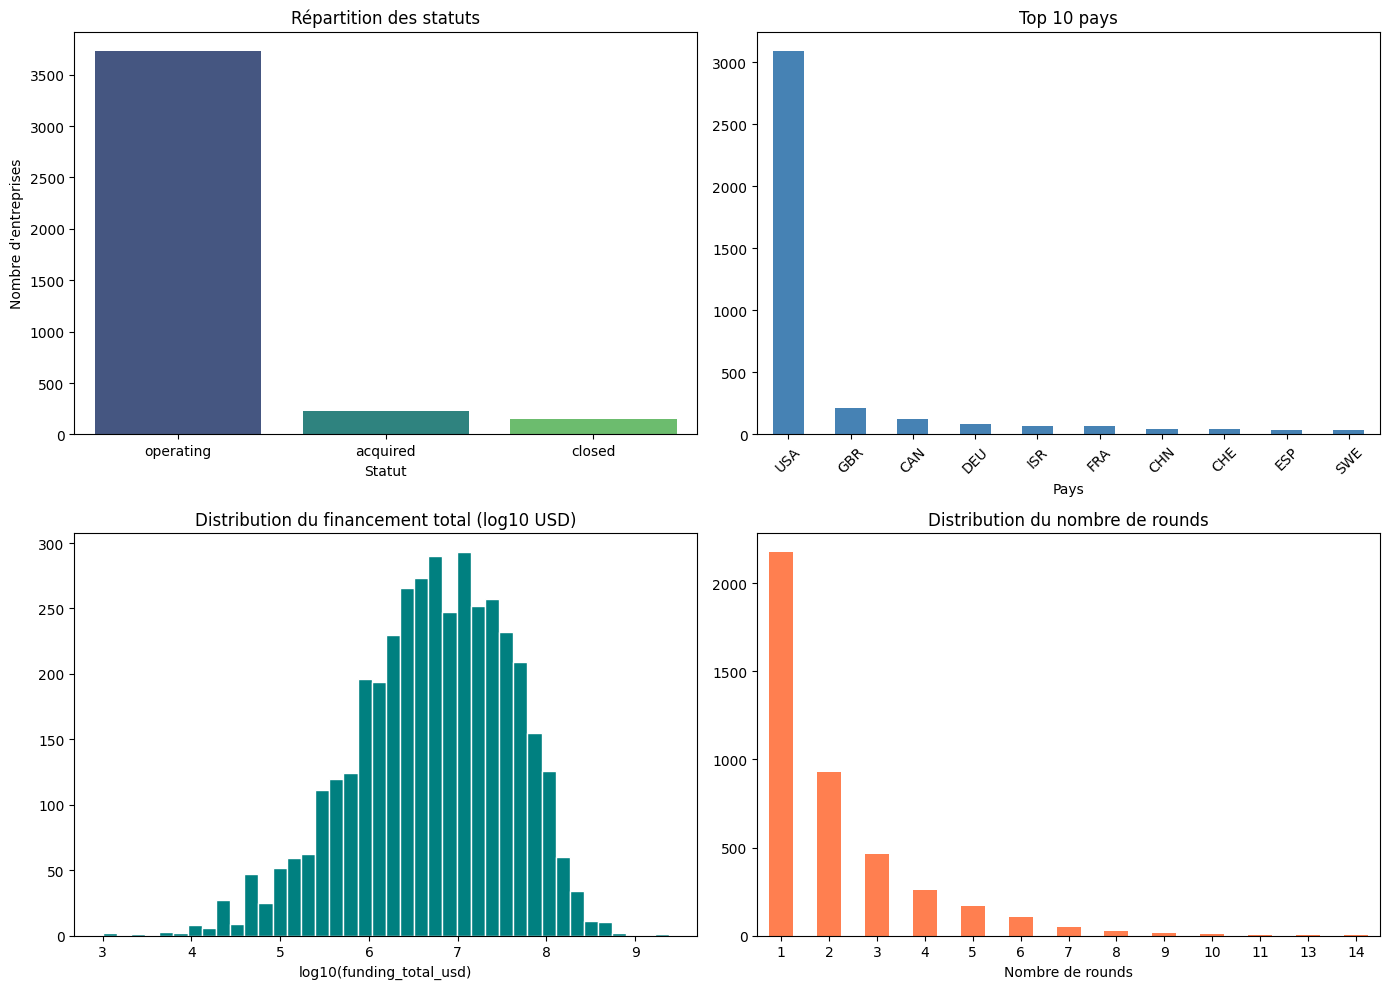

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=pharma_df, x='status', palette='viridis', ax=axes[0,0], hue='status', legend=False)
axes[0,0].set_title('Répartition des statuts')
axes[0,0].set_xlabel('Statut')
axes[0,0].set_ylabel("Nombre d'entreprises")

pharma_df['country_code'].value_counts().head(10).plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Top 10 pays')
axes[0,1].set_xlabel('Pays')
axes[0,1].tick_params(axis='x', rotation=45)

funding_clean = pharma_df['funding_total_usd'].dropna()
funding_clean = funding_clean[funding_clean > 0]
axes[1,0].hist(np.log10(funding_clean), bins=40, color='teal', edgecolor='white')
axes[1,0].set_title('Distribution du financement total (log10 USD)')
axes[1,0].set_xlabel('log10(funding_total_usd)')

pharma_df['funding_rounds'].dropna().astype(int).value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Distribution du nombre de rounds')
axes[1,1].set_xlabel('Nombre de rounds')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [ ]:
CUTOFF = '2012-01-01'
FUNDING_TYPES = ['seed', 'venture', 'grant', 'round_A', 'round_B']
COLS_NUMERIC = ['age', 'funding_total_usd', 'funding_rounds', 'days_to_first_funding',
                'funding_duration', 'funding_velocity', 'round_intensity']
FEATURES = COLS_NUMERIC + [f'has_{c}' for c in FUNDING_TYPES] + ['country_code']

In [ ]:
def build_features(df, reference_date, fit_country_encoder=False, rare_countries=None):
    d = df.copy()
    ref = pd.to_datetime(reference_date)

    d['funding_total_usd'] = pd.to_numeric(d['funding_total_usd'], errors='coerce')
    d['funding_total_usd'] = d['funding_total_usd'].fillna(d['funding_total_usd'].median())

    for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
        d[col] = pd.to_datetime(d[col], errors='coerce')

    d['age'] = ((ref - d['founded_at']).dt.days / 365.25).clip(lower=0.1)
    d['days_to_first_funding'] = (d['first_funding_at'] - d['founded_at']).dt.days
    last_funding_clipped = d['last_funding_at'].clip(upper=ref)
    d['funding_duration'] = (last_funding_clipped - d['first_funding_at']).dt.days

    d['funding_velocity'] = d['funding_total_usd'] / d['age']
    d['round_intensity']  = d['funding_rounds'] / d['age']

    for col in FUNDING_TYPES:
        d[f'has_{col}'] = (d[col].fillna(0) > 0).astype(int)

    for col in COLS_NUMERIC:
        d[col] = d.groupby('market')[col].transform(lambda x: x.fillna(x.median()))
        d[col] = d[col].fillna(d[col].median())

    if fit_country_encoder:
        country_counts = d['country_code'].value_counts()
        rare_countries = country_counts[country_counts < 5].index
    d['country_code'] = d['country_code'].replace(rare_countries, 'OTHER').fillna('UNKNOWN')

    if fit_country_encoder:
        return d, rare_countries
    return d

In [ ]:
ipo_mask = (
    (pd.to_numeric(pharma_df['post_ipo_equity'], errors='coerce') > 0) |
    (pd.to_numeric(pharma_df['post_ipo_debt'], errors='coerce') > 0)
)

train_raw = pharma_df[
    pharma_df['status'].isin(['acquired', 'closed']) |
    ((pharma_df['status'] == 'operating') & ipo_mask)
].copy()

train_data, rare_countries = build_features(train_raw, CUTOFF, fit_country_encoder=True)
train_data['Profitable'] = (
    (train_data['status'] == 'acquired') |
    (train_data['post_ipo_equity'] > 0) |
    (train_data['post_ipo_debt'] > 0)
).astype(int)

print(f"Startups d'entraînement : {len(train_data)}")
print(f"\nÉquilibre des classes :")
print(train_data['Profitable'].value_counts())
print(f"Taux de succès : {train_data['Profitable'].mean():.1%}")

X = pd.get_dummies(train_data[FEATURES], drop_first=True)
y = train_data['Profitable']
print(f"\nFeatures : {X.shape[1]}  |  NaN dans X : {X.isna().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_pipeline = Pipeline([
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('scaler', StandardScaler())
])
X_train_s = scaler_pipeline.fit_transform(X_train)
X_test_s  = scaler_pipeline.transform(X_test)

scaler_hgb = Pipeline([
    ('scaler', StandardScaler())
])
from sklearn.impute import SimpleImputer as _SI
_si_tmp = _SI(strategy='median')
X_train_hgb = scaler_hgb.fit_transform(_si_tmp.fit_transform(X_train))
X_test_hgb  = scaler_hgb.transform(_si_tmp.transform(X_test))

Startups d'entraînement : 480

Équilibre des classes :
Profitable
1    333
0    147
Name: count, dtype: int64
Taux de succès : 69.4%

Features : 21  |  NaN dans X : 0


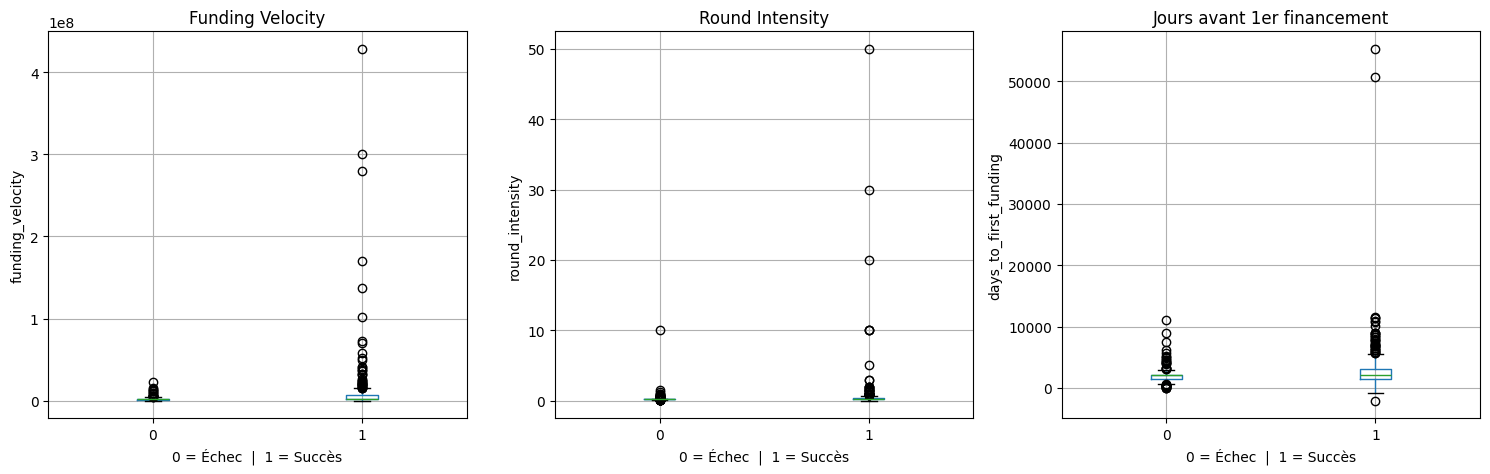

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
    ['funding_velocity', 'round_intensity', 'days_to_first_funding'],
    ['Funding Velocity', 'Round Intensity', 'Jours avant 1er financement']):
    train_data.boxplot(column=col, by='Profitable', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('0 = Échec  |  1 = Succès')
    ax.set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

Funding Velocity : On observe généralement que les startups qui réussissent (1) ont une "Funding Velocity" plus élevée que celles qui échouent (0). Cela suggère que les entreprises capables de lever des fonds plus rapidement par rapport à leur âge ont une plus grande probabilité de succès.

Round Intensity : Similairement, les boxplots montrent que les startups à succès ont tendance à avoir une "Round Intensity" plus forte. Cela signifie qu'elles réalisent plus de tours de financement par rapport à leur âge, indiquant une capacité continue à attirer des investisseurs.

Days to First Funding : Pour cette variable, les boxplots révèlent que les startups à succès (1) tendent à avoir un nombre de jours plus faible entre leur fondation et leur premier financement. Un délai court est interprété comme un indicateur positif, signalant une reconnaissance rapide par les investisseurs et potentiellement une meilleure dynamique de croissance.